<a href="https://colab.research.google.com/github/Gsmovidic/Entregable-1-Analisis-de-datos/blob/main/BD_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

##1️ Base de Datos 1 – Dataset de rendimiento estudiantil en los examenes.
 Fuente y tipo de datos
Fuente:  Secundaria, kaggle.
Link de la fuente: https://www.kaggle.com/datasets/grandmaster07/student-exam-performance-dataset-analysis/code

Tipo de datos: Tabular.

Formato: CSV.


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("grandmaster07/student-exam-performance-dataset-analysis")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-exam-performance-dataset-analysis' dataset.
Path to dataset files: /kaggle/input/student-exam-performance-dataset-analysis


In [108]:
pd.set_option("display.float_format", "{:.2f}".format)
data= pd.read_csv("/kaggle/input/student-exam-performance-dataset-analysis/StudentPerformanceFactors.csv")
data.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

Un total de 6607 filas con 20 columnas.


In [103]:
data.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [21]:
(data.isnull().sum() / len(data)) * 100

,0
Hours_Studied,0.00
Attendance,0.00
Parental_Involvement,0.00
Access_to_Resources,0.00
Extracurricular_Activities,0.00
Sleep_Hours,0.00
Previous_Scores,0.00
Motivation_Level,0.00
Internet_Access,0.00
Tutoring_Sessions,0.00


#Vamos a eliminar columnas nulas


In [109]:
data = data.drop(columns=[
    "Teacher_Quality",
    "Parental_Education_Level",
    "Distance_from_Home"
])

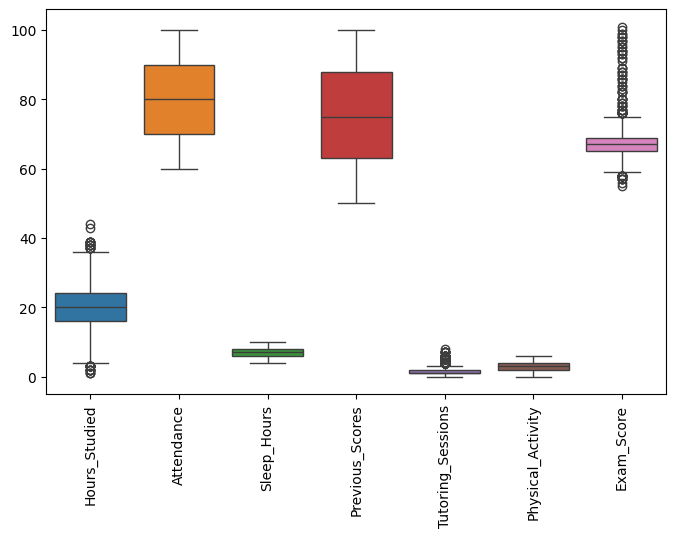

In [23]:


plt.figure(figsize=(8,5))
sns.boxplot(data=data.select_dtypes(include=['int64','float64']))
plt.xticks(rotation=90)
plt.show()

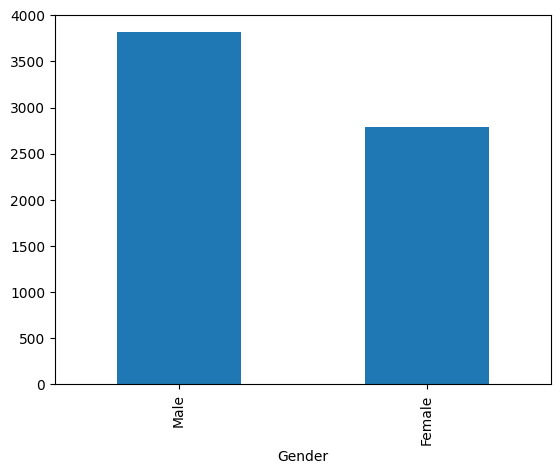

In [25]:
data['Gender'].value_counts().plot(kind='bar')
plt.show()

/tmp/ipykernel_1074/1712641831.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels() ,rotation=30)
/tmp/ipykernel_1074/1712641831.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels() ,rotation=30)
/tmp/ipykernel_1074/1712641831.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels() ,rotation=30)
/tmp/ipykernel_1074/1712641831.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels() ,rotation=30)
/tmp/ipykernel_1074/1712641831.py:11: UserWarning: set_ticklabels() should only be used 

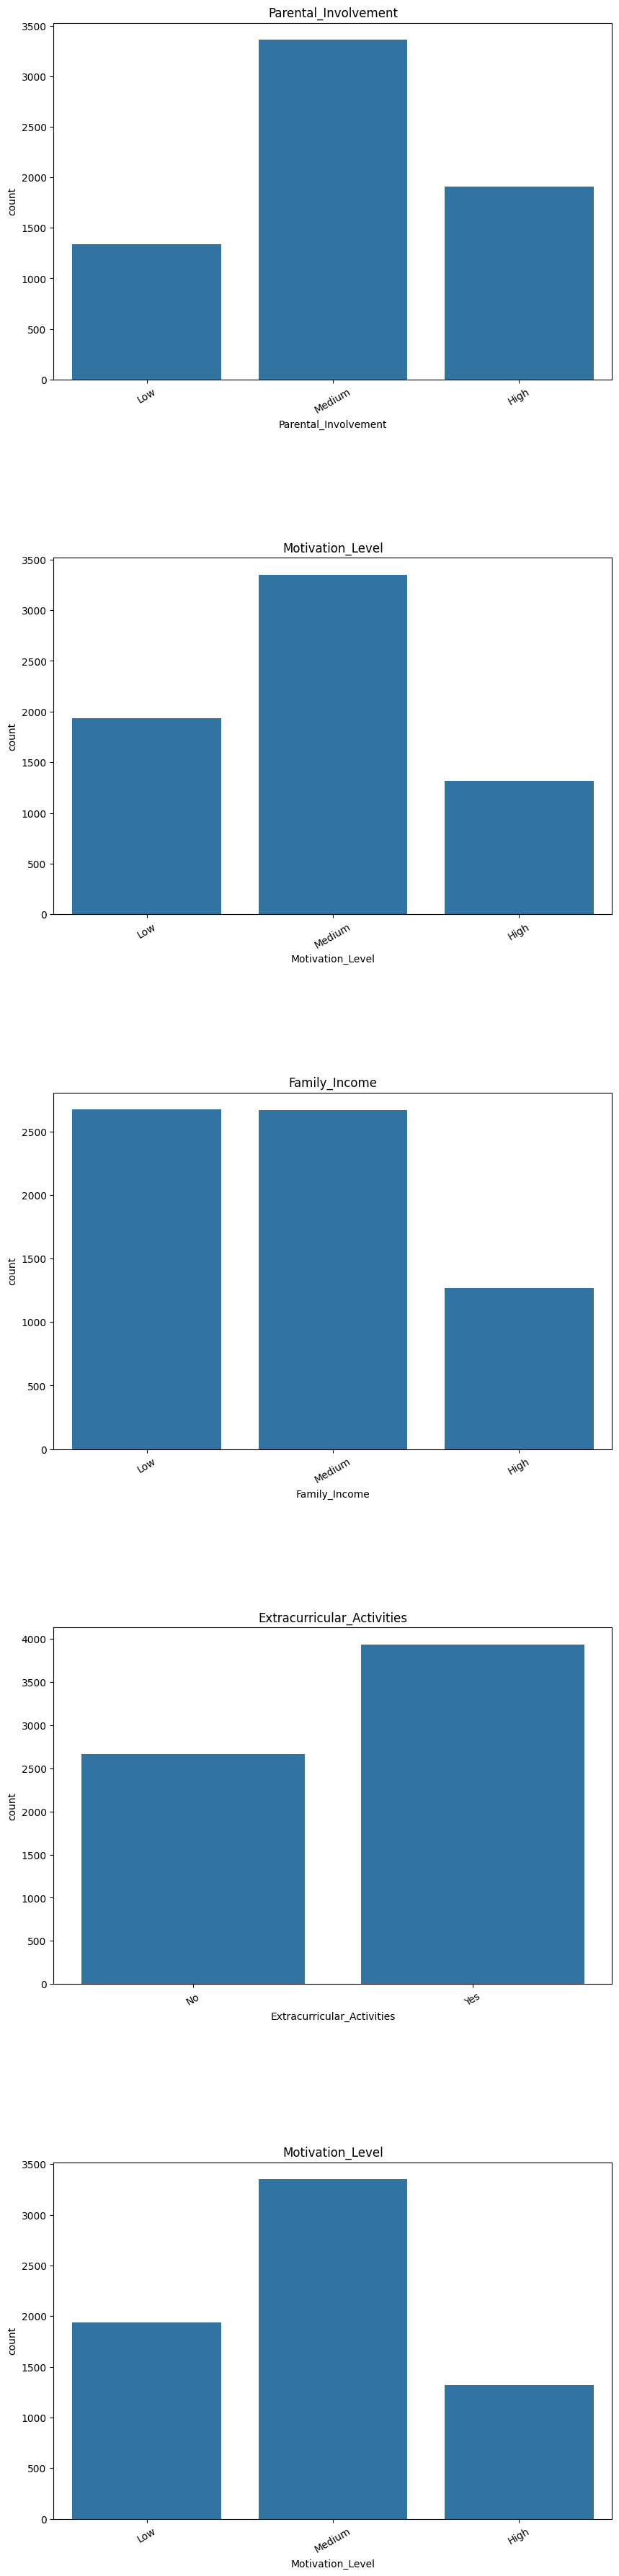

In [5]:
##tomemos las variables categoricas

col_cat=['Parental_Involvement','Motivation_Level','Family_Income','Extracurricular_Activities','Motivation_Level']

fig, ax= plt.subplots(nrows=len(col_cat), ncols=1, figsize=(10,45))
fig.subplots_adjust(hspace=0.5)

for i, col in enumerate(col_cat):
  sns.countplot(x=col, data=data , ax=ax[i])
  ax[i].set_title(col)
  ax[i].set_xticklabels(ax[i].get_xticklabels() ,rotation=30)

In [6]:
# Podemos extraer algunas variables estadísticas descriptivas básicas
data.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00
mean,19.98,79.98,7.03,75.07,1.49,2.97,67.24
std,5.99,11.55,1.47,14.40,1.23,1.03,3.89
min,1.00,60.00,4.00,50.00,0.00,0.00,55.00
25%,16.00,70.00,6.00,63.00,1.00,2.00,65.00
50%,20.00,80.00,7.00,75.00,1.00,3.00,67.00
75%,24.00,90.00,8.00,88.00,2.00,4.00,69.00
max,44.00,100.00,10.00,100.00,8.00,6.00,101.00


posibles aplicaciones.

-Modelo donde podamos predecir el puntaje

-Analisis de la importancia de las caracteristicas

-Insights de rendimiento educacional.

##FASE 2

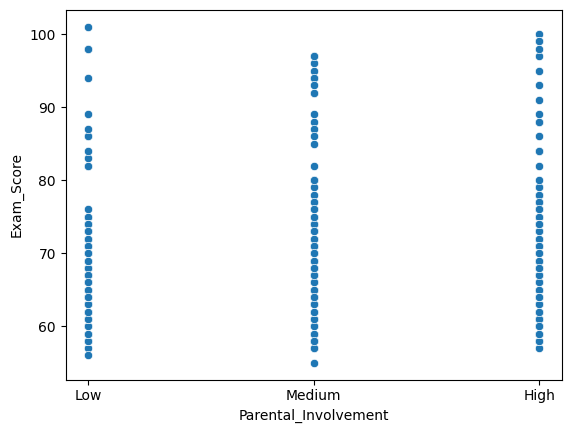

In [11]:
sns.scatterplot(data=data,x='Parental_Involvement',y='Exam_Score')
plt.show()

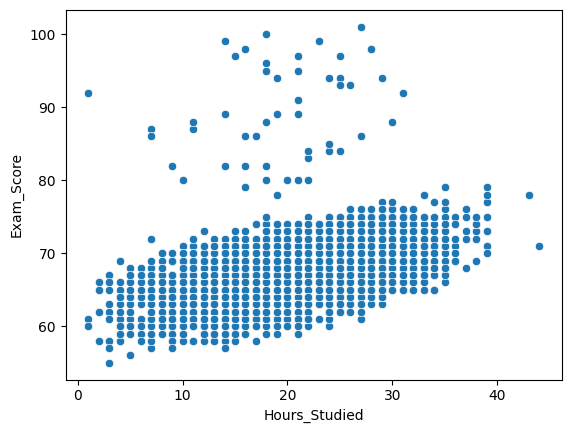

In [30]:
sns.scatterplot(data=data,x='Hours_Studied',y='Exam_Score')
plt.show()

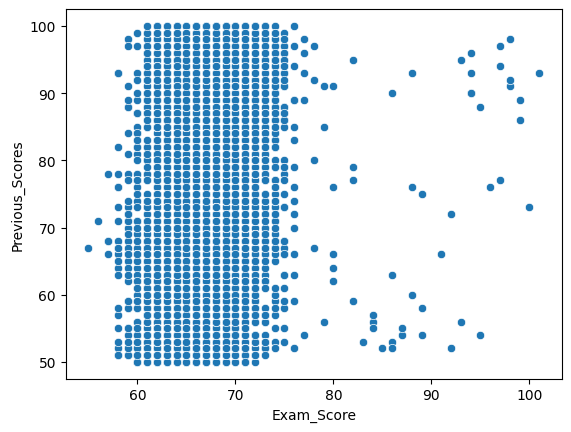

In [33]:
sns.scatterplot(data=data,x='Exam_Score',y='Previous_Scores')
plt.show()

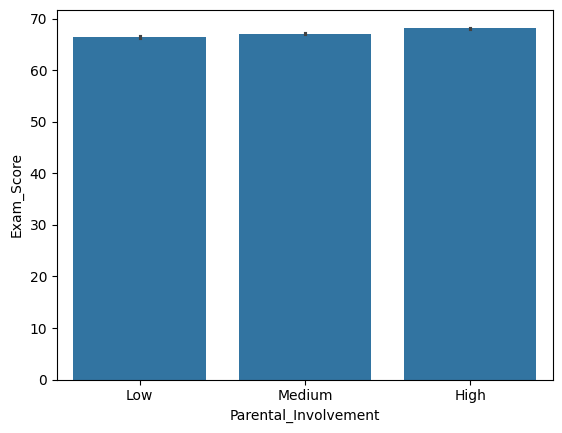

In [17]:
sns.barplot(data=data,x='Parental_Involvement',y='Exam_Score')
plt.show()
#

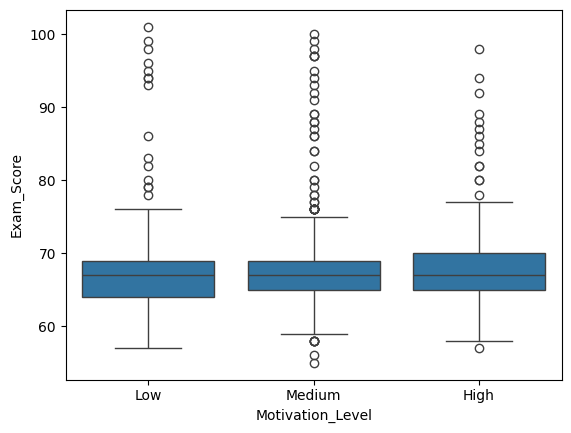

In [13]:
sns.boxplot(data=data,x='Motivation_Level',y='Exam_Score')
plt.show()

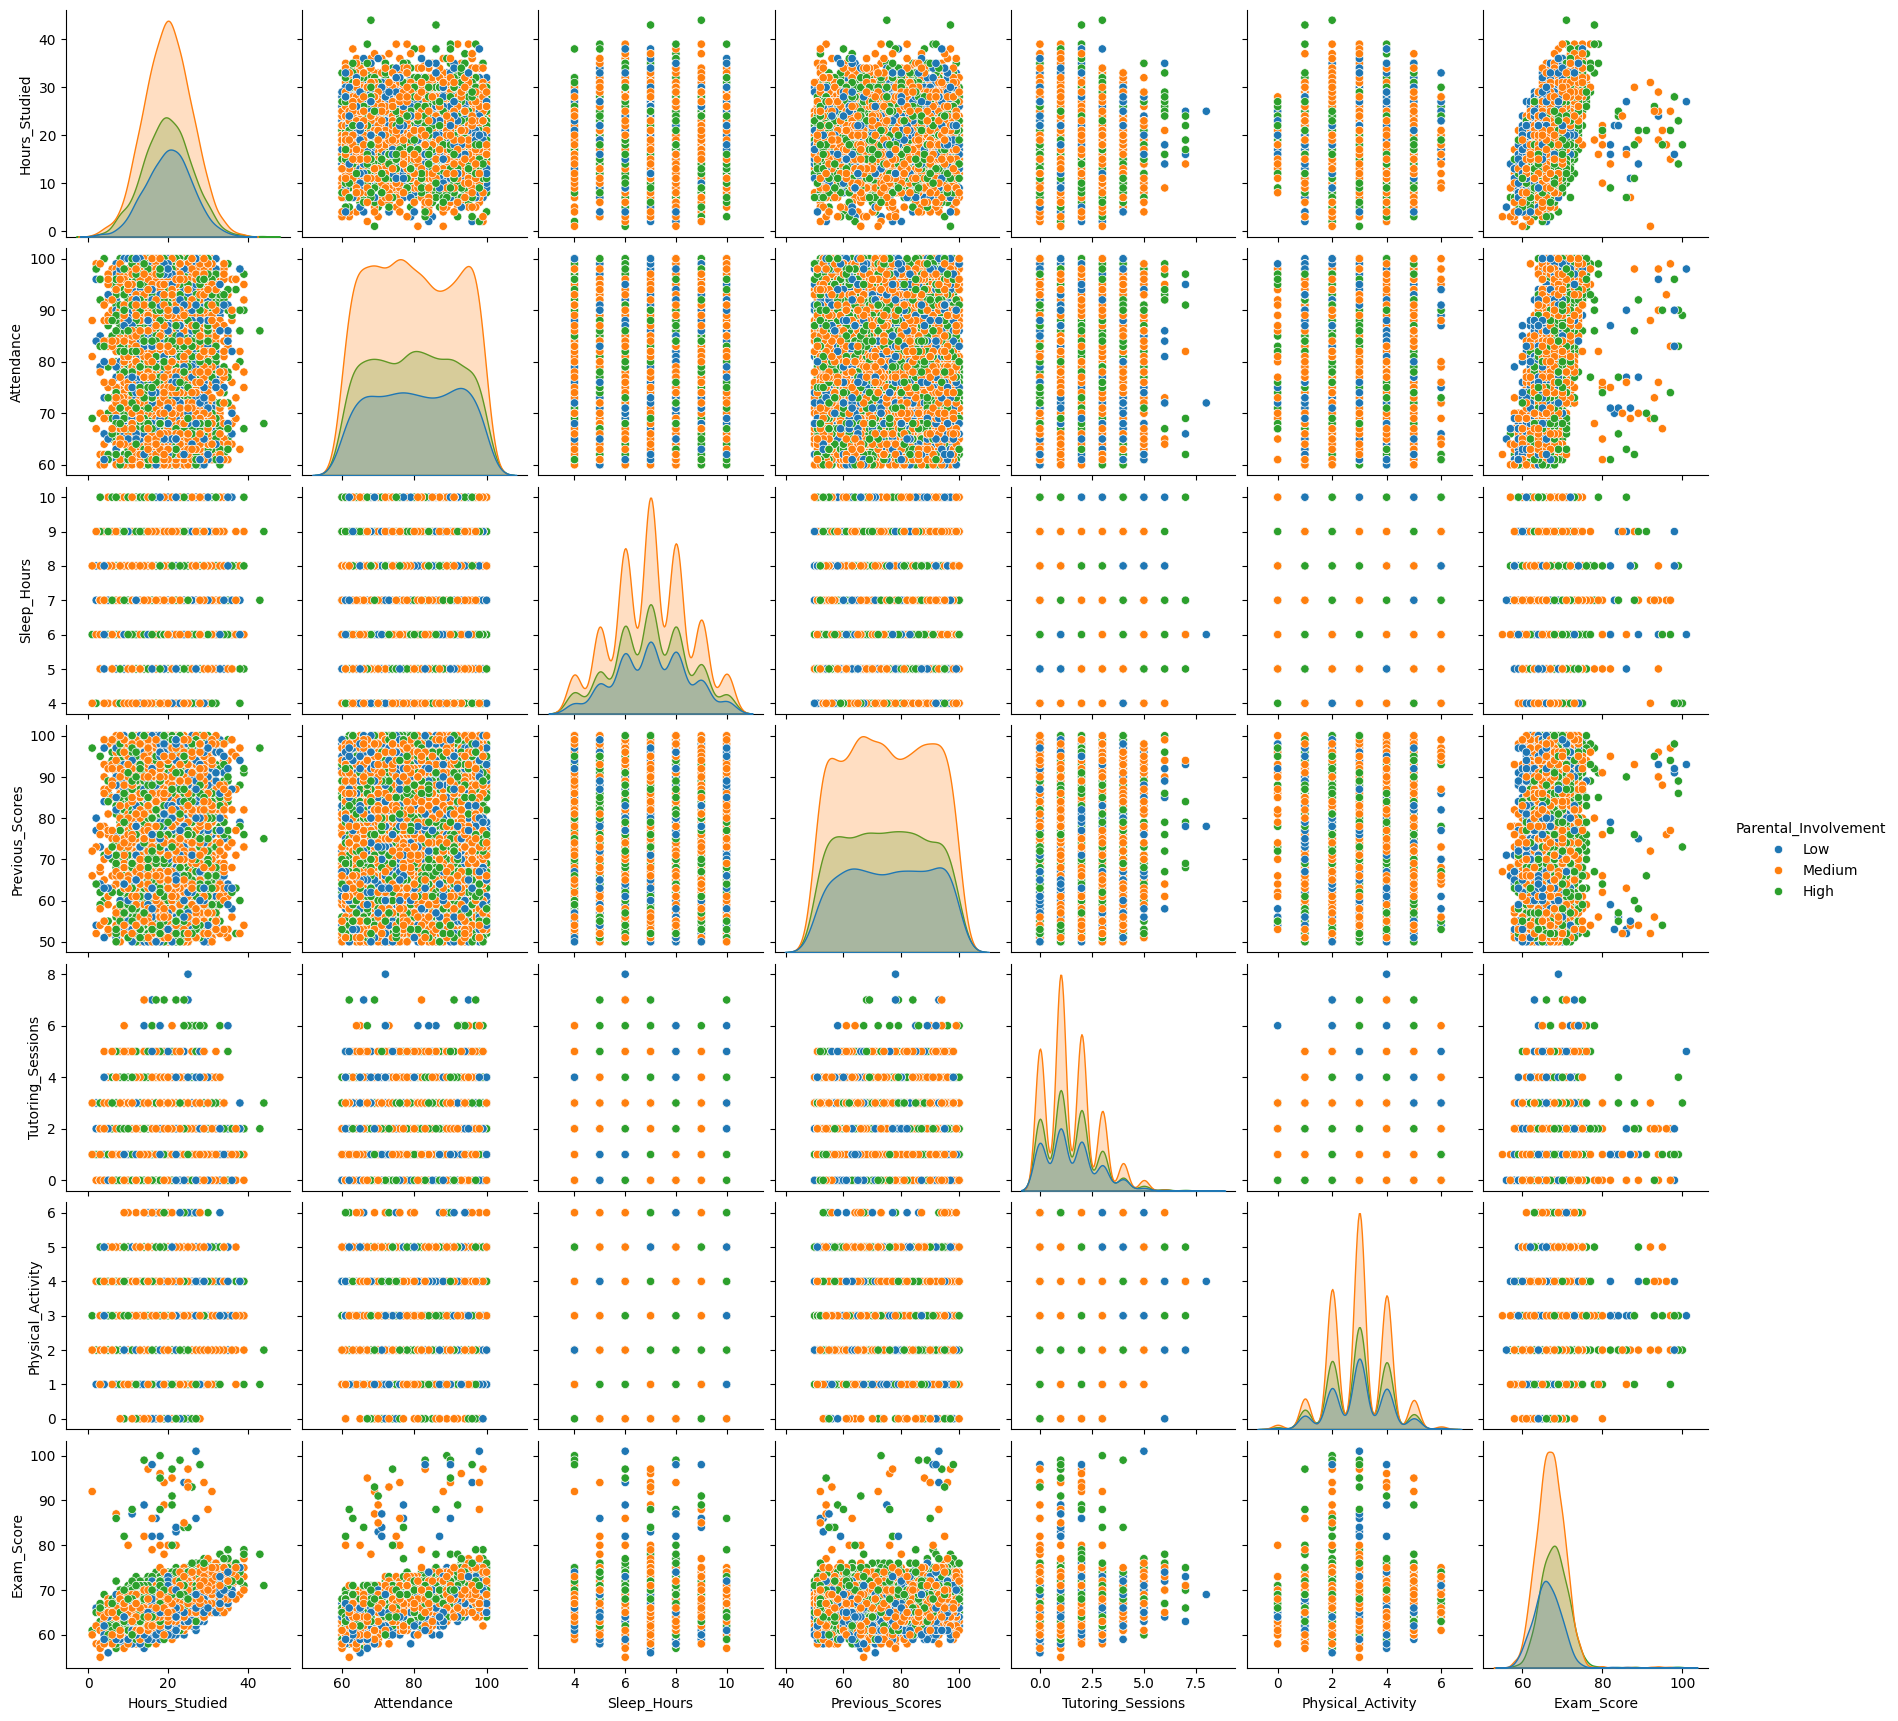

In [15]:
sns.pairplot(data, hue='Parental_Involvement')
plt.show()

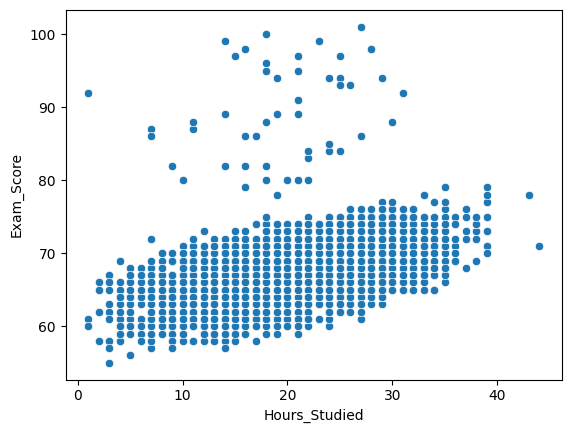

In [34]:
sns.scatterplot(x='Hours_Studied', y='Exam_Score', data=data)
plt.show()

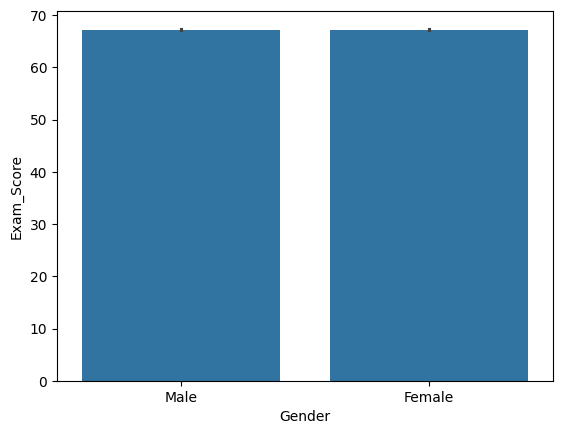

In [73]:
sns.barplot(x='Gender', y='Exam_Score', data=data)
plt.show()

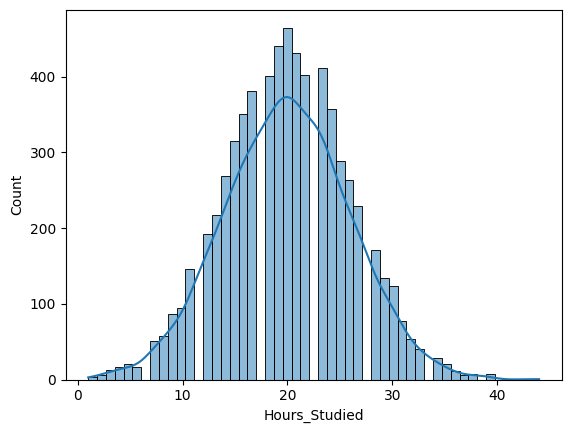

In [36]:
sns.histplot(data['Hours_Studied'], kde=True)
plt.show()

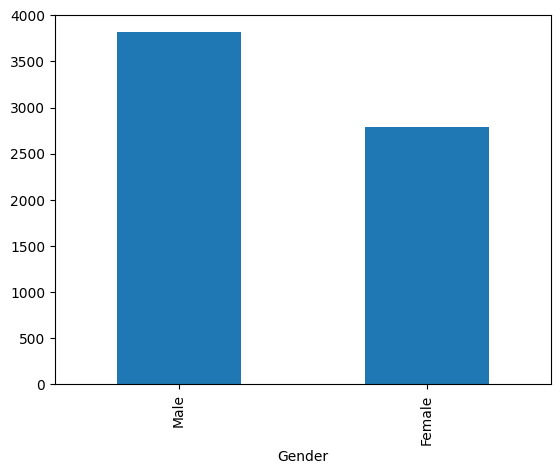

In [38]:
data['Gender'].value_counts().plot(kind='bar')
plt.show()

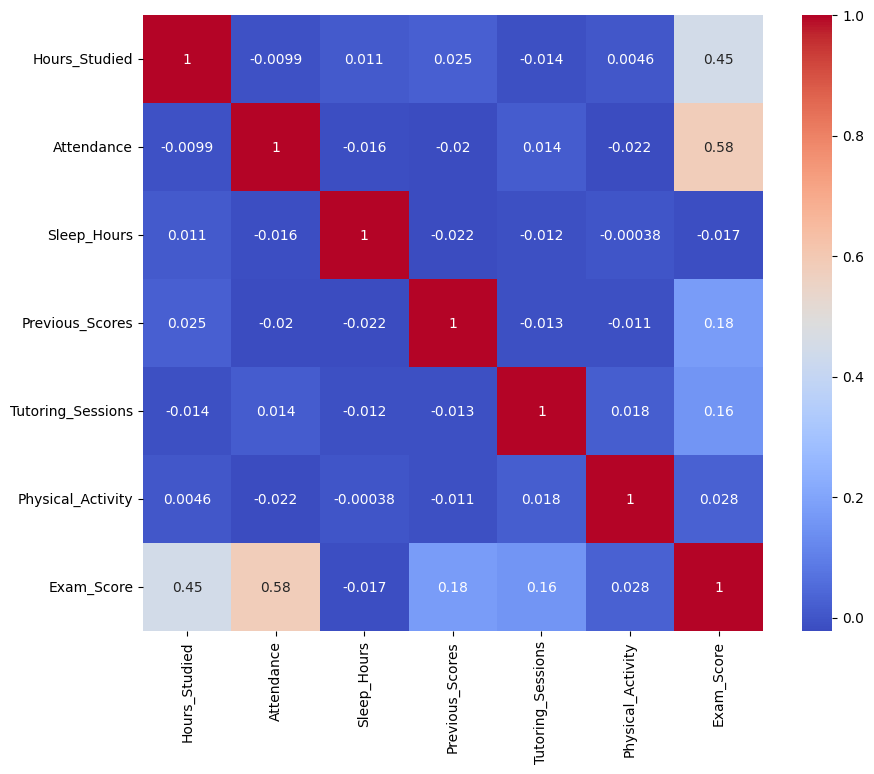

In [50]:
numeric_df = data.select_dtypes(include=[np.number])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=True)
plt.show()


#**Insights principales:**

1)Hay una relación entre las horas estudiadas y el puntaje del examen, que nos puede indicar que estudiar ayuda pero no explica todo el puntaje, deben haber otras variables que influyan en la obtención de un puntaje alto.


2)Entre la asistencia a clases y el puntaje del examen hay una relación moderada, en donde podriamos decir que asistir a clases influye mucho en el puntaje obtenido. Puede que ayude más que estudiar por aparte. En este orden de ideas, podriamos decir que asistir a clase ayuda más en obtener un buen puntaje en vez de estudiar mucho más.

3) El nivel de motivación no tiene mucha influencia sobre el puntaje obtenido, la media entre los 3 niveles es la misma o muy similar y los valores se distribuyen de manera muy uniforme entre las 3.

4)El apoyo de los padres no tiene mucha relevancia a la hora de obtener un buen puntaje, estos no muestran diferencia significativa entre los 3 niveles de apoyo.

5) El genero de la persona no influye en la obtención de su puntaje.


#Fase 3

In [110]:
ordinal_mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

In [111]:
data["Motivation_Level"] = data["Motivation_Level"].map(ordinal_mapping)
data["Parental_Involvement"] = data["Parental_Involvement"].map(ordinal_mapping)
data["Extracurricular_Activities"] = data["Extracurricular_Activities"].map(ordinal_mapping)
data["Family_Income"] = data["Family_Income"].map(ordinal_mapping)
data['Access_to_Resources']= data['Access_to_Resources'].map(ordinal_mapping)


In [112]:
data['Internet_Access'] = (data['Internet_Access'] == 'Yes').astype(int)
data['Extracurricular_Activities'] = (data['Extracurricular_Activities'] == 'Yes').astype(int)
data['Learning_Disabilities'] = (data['Learning_Disabilities'] == 'Yes').astype(int)
data['School_Type'] = (data['School_Type'] == 'Public').astype(int)

In [113]:
sentiment_mapping = {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2
}

data["Peer_Influence"] = data["Peer_Influence"].map(sentiment_mapping)


In [114]:
data = pd.get_dummies(data, columns=["Gender"], drop_first=True)

In [115]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   int64
 3   Access_to_Resources         6607 non-null   int64
 4   Extracurricular_Activities  6607 non-null   int64
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   int64
 8   Internet_Access             6607 non-null   int64
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   int64
 11  School_Type                 6607 non-null   int64
 12  Peer_Influence              6607 non-null   int64
 13  Physical_Activity           6607 non-null   int64
 14  Learning

#Escalado

In [116]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(data)



In [119]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
principal_components = pca.fit_transform(df_scaled)

print("Varianza explicada:", pca.explained_variance_ratio_)

Varianza explicada: [0.11351534 0.06741361]
